In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



In [74]:
#estrazione delle colonne necessarie in un nuovo dataset
df = pd.read_csv('dataset.csv')

selected_columns = [
    'Flotta', 'Veicolo', 'Codice', 'Nome', 'Descrizione', 'Test', 
    'Timestamp', 'Timestamp chiusura', 'Durata', 'Posizione', 
    'Sistema', 'Componente', 'Latitudine', 'Longitudine', 'Contemporaneo', 'Timestamp segnale'
]

filtered_df = df[selected_columns]

print(filtered_df.head())

filtered_df.to_csv('dataset_filtrato.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica


   Flotta    Veicolo  Codice            Nome  \
0  ETR700  e700_4801  085094    _SnsDmprY75_   
1  ETR700  e700_4801  011050  _HVACcabNotOK_   
2  ETR700  e700_4801  151014    _DCPantoSts_   
3  ETR700  e700_4801  151014    _DCPantoSts_   
4  ETR700  e700_4801  151014    _DCPantoSts_   

                                   Descrizione Test                Timestamp  \
0             Guasto al sensore del damper Y75    N  2022-03-14 14:04:24.901   
1  Perdita di comunicazione con HVAC cabina M1    N    2022-03-14 14:00:19.7   
2                     Pantografo DC alto in T2    N  2022-03-14 13:53:18.292   
3                     Pantografo DC alto in T2    N  2022-03-14 13:53:18.292   
4                     Pantografo DC alto in T2    N  2022-03-14 13:53:18.292   

        Timestamp chiusura  Durata Posizione  Sistema   Componente  \
0                      NaN     NaN    Milano     HVAC      HVAC_T5   
1  2022-03-14 14:00:39.502    20.0    Milano     HVAC  HVAC_CAB_M1   
2                   

In [75]:
#lista componenti in ordine di frequenza
component_counts = filtered_df['Componente'].value_counts()

component_counts.to_csv('classifica_componenti.csv', header=True) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [76]:
#creazione file filtrato per componente VEHICLE
df_vehicle = filtered_df[filtered_df['Componente'] == 'VEHICLE']

df_vehicle.to_csv('componente_vehicle.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [77]:
#classificazione delle descrizioni in base al tipo di evento
df_unique_description = df_vehicle[['Descrizione']].drop_duplicates()

key_words_anomalies = [
    'mancata', 'cod.', 'taglio', 'errore', 'scarica', 'guasto', 'incoerenza', 'errata'
]
key_words_normal = ['stato attivo', 'running', 'standby', 'parking', 'comando']

def classifica_evento_vehicle(descrizione):
    descrizione_lower = descrizione.lower()
    if any(parola in descrizione_lower for parola in key_words_anomalies):
        return 'Anomalia'
    else:
        return 'Funzionamento Normale'

df_unique_description['Tipo_Evento'] = df_unique_description['Descrizione'].apply(classifica_evento_vehicle)

df_unique_description.to_csv('descrizioni_vehicle_classificate.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

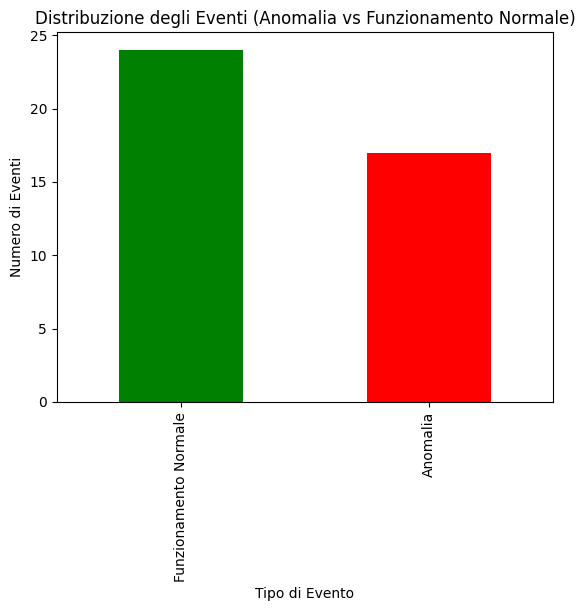

In [78]:
#visualizzazione della distribuzione degli eventi
event_type = df_unique_description['Tipo_Evento'].value_counts()

event_type.plot(kind='bar', color=['green', 'red'])
plt.title('Distribuzione degli Eventi (Anomalia vs Funzionamento Normale)')
plt.xlabel('Tipo di Evento')
plt.ylabel('Numero di Eventi')
plt.show()

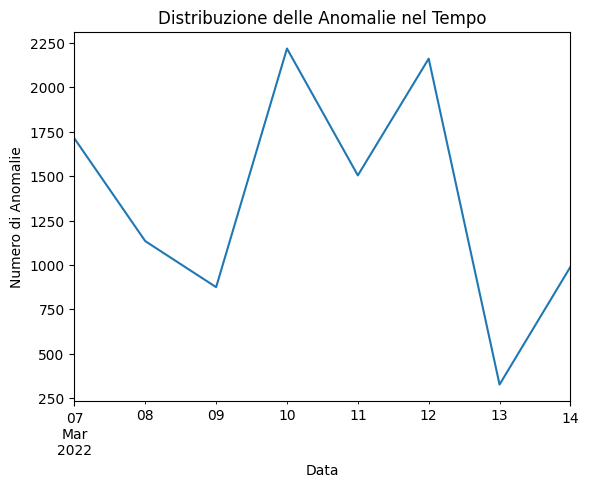

In [79]:
#visualizzazione della distribazione delle anomalie nel tempo
df_vehicle = df_vehicle.merge(df_unique_description[['Descrizione', 'Tipo_Evento']], on='Descrizione', how='left')

df_vehicle['Timestamp'] = pd.to_datetime(df_vehicle['Timestamp'], errors='coerce')
df_anomalies = df_vehicle[df_vehicle['Tipo_Evento'] == 'Anomalia'].dropna(subset=['Timestamp'])

import matplotlib.pyplot as plt
df_anomalies.set_index('Timestamp').resample('D').size().plot(title='Distribuzione delle Anomalie nel Tempo')
plt.xlabel('Data')
plt.ylabel('Numero di Anomalie')
plt.show()

In [80]:
#creazione file filtrato per componente VEHICLE
df_vehicle_complete  = df[df['Componente'] == 'VEHICLE']

df_vehicle_complete .to_csv('componente_vehicle_completo.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [81]:
#unione dei dataset
df_complete = df_vehicle_complete.merge(df_unique_description[['Descrizione', 'Tipo_Evento']], on='Descrizione', how='left')

df_complete.to_csv('componente_vehicle_completo_classificato.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [82]:
#pulizia dataset da colonne vuote
columns_with_only_nulls = df_complete.columns[df_complete.isnull().all()]

df_cleaned = df_complete.drop(columns=columns_with_only_nulls)

columns_with_only_nulls.tolist()

['1K7OverCrrnt_T2',
 '1K7OverCrrnt_T7',
 '1KD1Alrm_T2',
 '1KD1Alrm_T7',
 'ACPntSts_Cnfg1',
 'ACPntSts_T2',
 'ACPntSts_T7',
 'ACPntSts_rem4',
 'AlpMngLowPanto',
 'CCU_M1_RDI5_2',
 'CCU_M8_RDI5_2',
 'CabEnabled',
 'CmdPntIdu2_T2',
 'CmdPntIdu2_T7',
 'DCPntSts_T2',
 'DCPntSts_T7',
 'DIS_VelPdC',
 'DS1833_Life',
 'DS2833_Life',
 'HMI_IBatt_T2',
 'HMI_IBatt_T4',
 'HMI_IBatt_T5',
 'HMI_IBatt_T7',
 'HMI_Vbatt_min',
 'HscbFlt_T2',
 'HscbFlt_T7',
 'LCU5_T2_RDI1',
 'LCU5_T2_RDI2',
 'LCU5_T2_RDI4',
 'LCU5_T7_RDI1',
 'LCU5_T7_RDI2',
 'LCU5_T7_RDI4',
 'LevSforzoNoNeut',
 'M1_CcuSts6',
 'M1_CcuSts7',
 'M1_PntLowMacroCondition1d',
 'M1_PntLowMacroCondition21d',
 'M1_PntLowMacroCondition2d',
 'M1_PntLowMacroCondition3',
 'M1_T5Diag',
 'M1_T5Sts',
 'M8_CcuSts6',
 'M8_CcuSts7',
 'M8_PntLowMacroCondition1d',
 'M8_PntLowMacroCondition21d',
 'M8_PntLowMacroCondition2d',
 'M8_PntLowMacroCondition3',
 'M8_T5Diag',
 'M8_T5Sts',
 'MDS_T2_IlckMcbOpenReq1',
 'MDS_T2_IlckMcbOpenReq2',
 'MDS_T7_IlckMcbOpenReq1',
 

In [83]:
#normalizzazione delle colonne
df_cleaned['Descrizione_Classificata'] = df_cleaned['Descrizione'].astype('category').cat.codes + 1

df_cleaned['Tipo_Evento_Classificato'] = df_cleaned['Tipo_Evento'].apply(lambda x: 1 if x == 'Funzionamento Normale' else 0)

df_cleaned.head()

,Flotta,Veicolo,Codice,Nome,Descrizione,Test,Timestamp,Timestamp chiusura,Durata,Posizione,...,usB2BCilPres_M8,usB2BCilPres_T2,usB2BCilPres_T4,usB2BCilPres_T5,usB2BCilPres_T7,usBpPres,usMpPres,Tipo_Evento,Descrizione_Classificata,Tipo_Evento_Classificato
0,ETR700,e700_4801,151014,_DCPantoSts_,Pantografo DC alto in T2,N,2022-03-14 13:53:18.292,NaN,NaN,NaN,...,2.58,2.43,2.12,2.18,2.55,0.0,8.60,Funzionamento Normale,32,1
1,ETR700,e700_4801,151014,_DCPantoSts_,Pantografo DC alto in T2,N,2022-03-14 13:53:18.292,NaN,NaN,NaN,...,2.58,2.43,2.12,2.18,2.55,0.0,8.60,Funzionamento Normale,32,1
2,ETR700,e700_4801,151014,_DCPantoSts_,Pantografo DC alto in T2,N,2022-03-14 13:53:18.292,NaN,NaN,NaN,...,2.58,2.43,2.12,2.18,2.55,0.0,8.61,Funzionamento Normale,32,1
3,ETR700,e700_4801,150007,_Standby_,Stato STANDBY attivo,N,2022-03-14 13:53:14.106,NaN,NaN,Milano,...,2.58,2.43,2.12,2.18,2.55,0.0,8.54,Funzionamento Normale,41,1
4,ETR700,e700_4801,150007,_Standby_,Stato STANDBY attivo,N,2022-03-14 13:53:14.106,NaN,NaN,Milano,...,2.58,2.43,2.12,2.18,2.56,0.0,8.54,Funzionamento Normale,41,1


In [84]:
# Rimuoviamo le righe che contengono valori NaN
df_cleaned_no_nan = df_cleaned.dropna()

# Verifichiamo che non ci siano più valori NaN
df_cleaned_no_nan.isnull().sum().sum(), df_cleaned_no_nan.shape

df_cleaned_no_nan.to_csv('dataset_cleaned.csv', index=False) #ho salvato i nuovi file per poterli vedere e capire la struttura, non ha un'utilità pratica

In [85]:
#creatzione modello e valutazione accuratezza
X_final = df_cleaned_no_nan.drop(columns=['Tipo_Evento_Classificato', 'Descrizione_Classificata', 'Tipo_Evento', 'Descrizione', 'Timestamp', 'Timestamp chiusura', 'Durata', 'Posizione', 'Flotta', 'Veicolo', 'Codice', 'Nome', 'Test'])

y_final = df_cleaned_no_nan['Tipo_Evento_Classificato']

y_final = y_final.replace({1: 'Funzionamento Normale', 0: 'Anomalia'})

non_numeric_columns = X_final.select_dtypes(include=['object']).columns

X_final = X_final.drop(columns=non_numeric_columns)

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Anomalia', 'Funzionamento Normale'])

print(f"Accuratezza del modello: {accuracy:.4f}")
print("Report di classificazione:")
print(classification_rep)


Accuratezza del modello: 0.8834
Report di classificazione:
                       precision    recall  f1-score   support

             Anomalia       0.91      0.93      0.92      2176
Funzionamento Normale       0.78      0.72      0.75       696

             accuracy                           0.88      2872
            macro avg       0.85      0.83      0.84      2872
         weighted avg       0.88      0.88      0.88      2872

